[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv12 Object Detection on a Custom Dataset

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolov12-object-detection-model.ipynb)
[![arXiv](https://img.shields.io/badge/arXiv-2502.12524-b31b1b.svg)](https://arxiv.org/abs/2502.12524)
[![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/train-yolov12-model)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/sunsmarterjie/yolov12)

[YOLOv12](https://github.com/sunsmarterjie/yolov12) is a newly proposed attention-centric variant of the YOLO family that focuses on incorporating efficient attention mechanisms into the backbone while preserving real-time performance. Instead of relying heavily on CNN-based architectures like its predecessors, YOLOv12 introduces a simple yet powerful “area attention” module, which strategically partitions the feature map to reduce the quadratic complexity of full self-attention. It also adopts residual efficient layer aggregation networks (R-ELAN) to enhance feature aggregation and training stability, especially for larger models. These innovations, together with refinements such as scaled residual connections and a reduced MLP ratio, enable YOLOv12 to harness the benefits of attention (e.g., better global context modeling) without sacrificing speed.

![yolov12-area-attention](https://media.roboflow.com/notebooks/examples/yolov12-area-attention.png)

Compared to prior YOLO iterations (e.g., YOLOv10, YOLOv11, and YOLOv8), YOLOv12 achieves higher detection accuracy with competitive or faster inference times across all model scales. Its five sizes—N, S, M, L, and X—range from 2.6M to 59.1M parameters, striking a strong accuracy–speed balance. For instance, the smallest YOLOv12-N surpasses other “nano” models by over 1% mAP with latency around 1.6 ms on a T4 GPU, and the largest YOLOv12-X achieves 55.2% mAP, comfortably outscoring comparable real-time detectors such as RT-DETR and YOLOv11-X . By matching or exceeding state-of-the-art accuracy while remaining fast, YOLOv12 represents a notable step forward for attention-based real-time object detection.

![yolov12-metrics](https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/yolov12-metrics.png)

## Environment setup

### Configure your API keys

To fine-tune YOLOv12, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

In [1]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

### Check GPU availability

**NOTE:** **YOLOv12 leverages FlashAttention to speed up attention-based computations, but this feature requires an Nvidia GPU built on the Ampere architecture or newer—for example, GPUs like the RTX 3090, RTX 3080, or even the Nvidia L4 meet this requirement.**

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [2]:
!nvidia-smi

Sun Mar 23 14:48:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


### Install dependencies

**NOTE:** Currently, YOLOv12 does not have its own PyPI package, so we install it directly from GitHub while also adding roboflow (to conveniently pull datasets from the Roboflow Universe), supervision (to visualize inference results and benchmark the model’s performance), and flash-attn (to accelerate attention-based computations via optimized CUDA kernels).

In [4]:
!pip install -q git+https://github.com/sunsmarterjie/yolov12.git roboflow supervision flash-attn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.5/84.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

### Download example data

Let's download an image we can use for YOLOv12 inference. Feel free to drag and drop your own images into the Files tab on the left-hand side of Google Colab, then reference their filenames in your code for a custom inference demo.

In [5]:
!wget https://media.roboflow.com/notebooks/examples/dog.jpeg

--2025-03-23 14:51:44--  https://media.roboflow.com/notebooks/examples/dog.jpeg
Resolving media.roboflow.com (media.roboflow.com)... 34.110.133.209
Connecting to media.roboflow.com (media.roboflow.com)|34.110.133.209|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 106055 (104K) [image/jpeg]
Saving to: ‘dog.jpeg’

dog.jpeg            100%[===================>] 103.57K  --.-KB/s    in 0.001s  

2025-03-23 14:51:44 (80.1 MB/s) - ‘dog.jpeg’ saved [106055/106055]



## Run inference

In the example, we're using the `yolov12l.pt` model, but you can experiment with different model sizes by simply swapping out the model name during initialization. Options include `yolov12n.pt`, `yolov12s.pt`, `yolov12m.pt`, `yolov12l.pt`, and `yolov12x.pt`.

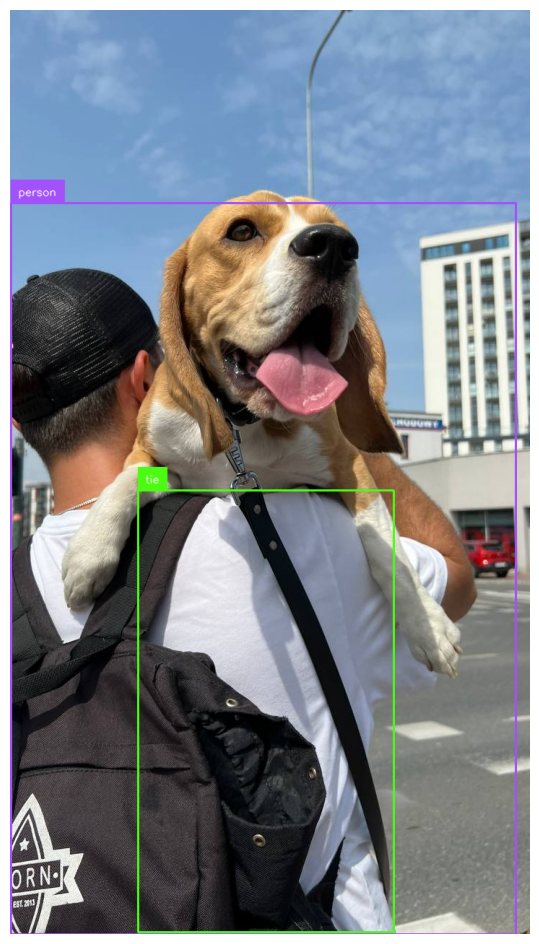

In [13]:
import cv2
from ultralytics import YOLO
import supervision as sv


image_path = f"{HOME}/dog.jpeg"
image = cv2.imread(image_path)

model = YOLO('yolov12m.pt')

results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

## Download dataset from Roboflow Universe

In [15]:
from roboflow import download_dataset
from roboflow import Roboflow

#dataset = download_dataset('https://universe.roboflow.com/roboflow-100/circuit-voltages/dataset/2', 'yolov8')


!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("liangdianzhong")
project = rf.workspace("ships-kev8a").project("military-ship-detection")
version = project.version(48)
dataset = version.download("yolov11")


/content/datasets
loading Roboflow workspace...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Military-Ship-Detection-48 in yolov11:: 100%|██████████| 5070/5070 [00:00<00:00, 6185.85it/s]


In [16]:
!ls {dataset.location}

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


**NOTE:** We need to make a few changes to our downloaded dataset so it will work with YOLOv12. Run the following bash commands to prepare your dataset for training by updating the relative paths in the `data.yaml` file, ensuring it correctly points to the subdirectories for your dataset's `train`, `test`, and `valid` subsets.

In [17]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

In [18]:
!cat {dataset.location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 47
names: ['Aircraft-Carrier-Fujian-Class-CHI', 'Aircraft-Carrier-Kiev Class-IND', 'Aircraft-Carrier-Kuznetsov-Class-CHI', 'Aircraft-Carrier-Vikrant-Class-IND', 'Corvette-Azmat-Class-PAK', 'Corvette-Babur-Class-PAK', 'Corvette-Jiangdao-class-056-CHI', 'Corvette-Kamorta-Class-IND', 'Corvette-Khukri-Class-IND', 'Corvette-Kora-Class-IND', 'Corvette-Veer-Class-IND', 'Corvette-Yarmook-Class-PAK', 'Destroyer-Delhi-Class-IND', 'Destroyer-Kolkata-Class-IND', 'Destroyer-Luyang-III-class-052-CHI', 'Destroyer-Rajput-Class-IND', 'Destroyer-Renhai-Class-055-CHI', 'Destroyer-Visakhapatnam-Class-IND', 'Frigate-Brahmaputra-Class-IND', 'Frigate-Godavari-Class-IND', 'Frigate-Shivalik-Class-IND', 'Frigate-Talwar-Class-IND', 'Frigate-Tughril-Class-PAK', 'Frigate-Zulfiquar-Class-PAK', 'Landing-Ship-Austin-Class-IND', 'Landing-Ship-Magar-Class-IND', 'Landing-Ship-Shardul-Class-IND', 'Landing-Ship-Yushen-Class-075-CHI', 'Minesweeper-Pondic

## Fine-tune YOLOv12 model

We are now ready to fine-tune our YOLOv12 model. In the code below, we initialize the model using a starting checkpoint—here, we use `yolov12s.yaml`, but you can replace it with any other model (e.g., `yolov12n.pt`, `yolov12m.pt`, `yolov12l.pt`, or `yolov12x.pt`) based on your preference. We set the training to run for 100 epochs in this example; however, you should adjust the number of epochs along with other hyperparameters such as batch size, image size, and augmentation settings (scale, mosaic, mixup, and copy-paste) based on your hardware capabilities and dataset size.

**Note:** **Note that after training, you might encounter a `TypeError: argument of type 'PosixPath' is not iterable error` — this is a known issue, but your model weights will still be saved, so you can safely proceed to running inference.**

In [19]:
from ultralytics import YOLO

model = YOLO('yolov12m.pt')

results = model.train(data=f'{dataset.location}/data.yaml', epochs=65)

100%|██████████| 38.0M/38.0M [00:00<00:00, 193MB/s]


New https://pypi.org/project/ultralytics/8.3.94 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.63 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov12m.pt, data=/content/datasets/Military-Ship-Detection-48/data.yaml, epochs=65, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=N

100%|██████████| 755k/755k [00:00<00:00, 14.5MB/s]


Overriding model.yaml nc=80 with nc=47

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     37120  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2, 1, 2]         
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    147968  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2, 1, 4]        
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  2   2664960  ultralytics.nn.modules.block.A2C2f           [512, 512, 2, True, 4]        
  7                  -1  1   2360320  ultralytic

100%|██████████| 5.26M/5.26M [00:00<00:00, 63.3MB/s]


...

      65/65      12.4G     0.2966     0.2636     0.9486          2        640: 100%|██████████| 116/116 [01:47<00:00,  1.08it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:08<00:00,  1.57it/s]

                   all        436        460      0.764      0.691      0.769      0.693



65 epochs completed in 2.161 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 39.8MB
Optimizer stripped from runs/detect/train/weights/best.pt, 39.8MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.63 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv12m summary (fused): 402 layers, 19,612,765 parameters, 0 gradients, 59.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 14/14 [00:10<00:00,  1.38it/s]


                   all        436        460      0.718      0.742      0.779      0.698
Aircraft-Carrier-Fujian-Class-CHI          7          7      0.572      0.857      0.884      0.748
Aircraft-Carrier-Kiev Class-IND         12         12      0.776      0.868      0.926      0.861
Aircraft-Carrier-Kuznetsov-Class-CHI          9          9      0.583      0.667      0.747      0.699
Aircraft-Carrier-Vikrant-Class-IND         15         15      0.753      0.867      0.803      0.732
Corvette-Azmat-Class-PAK          2          2      0.242        0.5       0.25        0.2
Corvette-Babur-Class-PAK         10         10      0.658        0.6      0.739      0.683
Corvette-Jiangdao-class-056-CHI          9         15      0.883      0.505      0.678      0.524
Corvette-Kamorta-Class-IND         17         18      0.887      0.778      0.832      0.788
Corvette-Khukri-Class-IND          5          5      0.531      0.462      0.609      0.575
Corvette-Kora-Class-IND         11         1

## Evaluate fine-tuned YOLOv12 model

In [20]:
import locale
locale.getpreferredencoding = lambda: "UTF-8"

!ls {HOME}/content/datasets/runs/detect/train



ls: cannot access '/content/content/datasets/runs/detect/train': No such file or directory


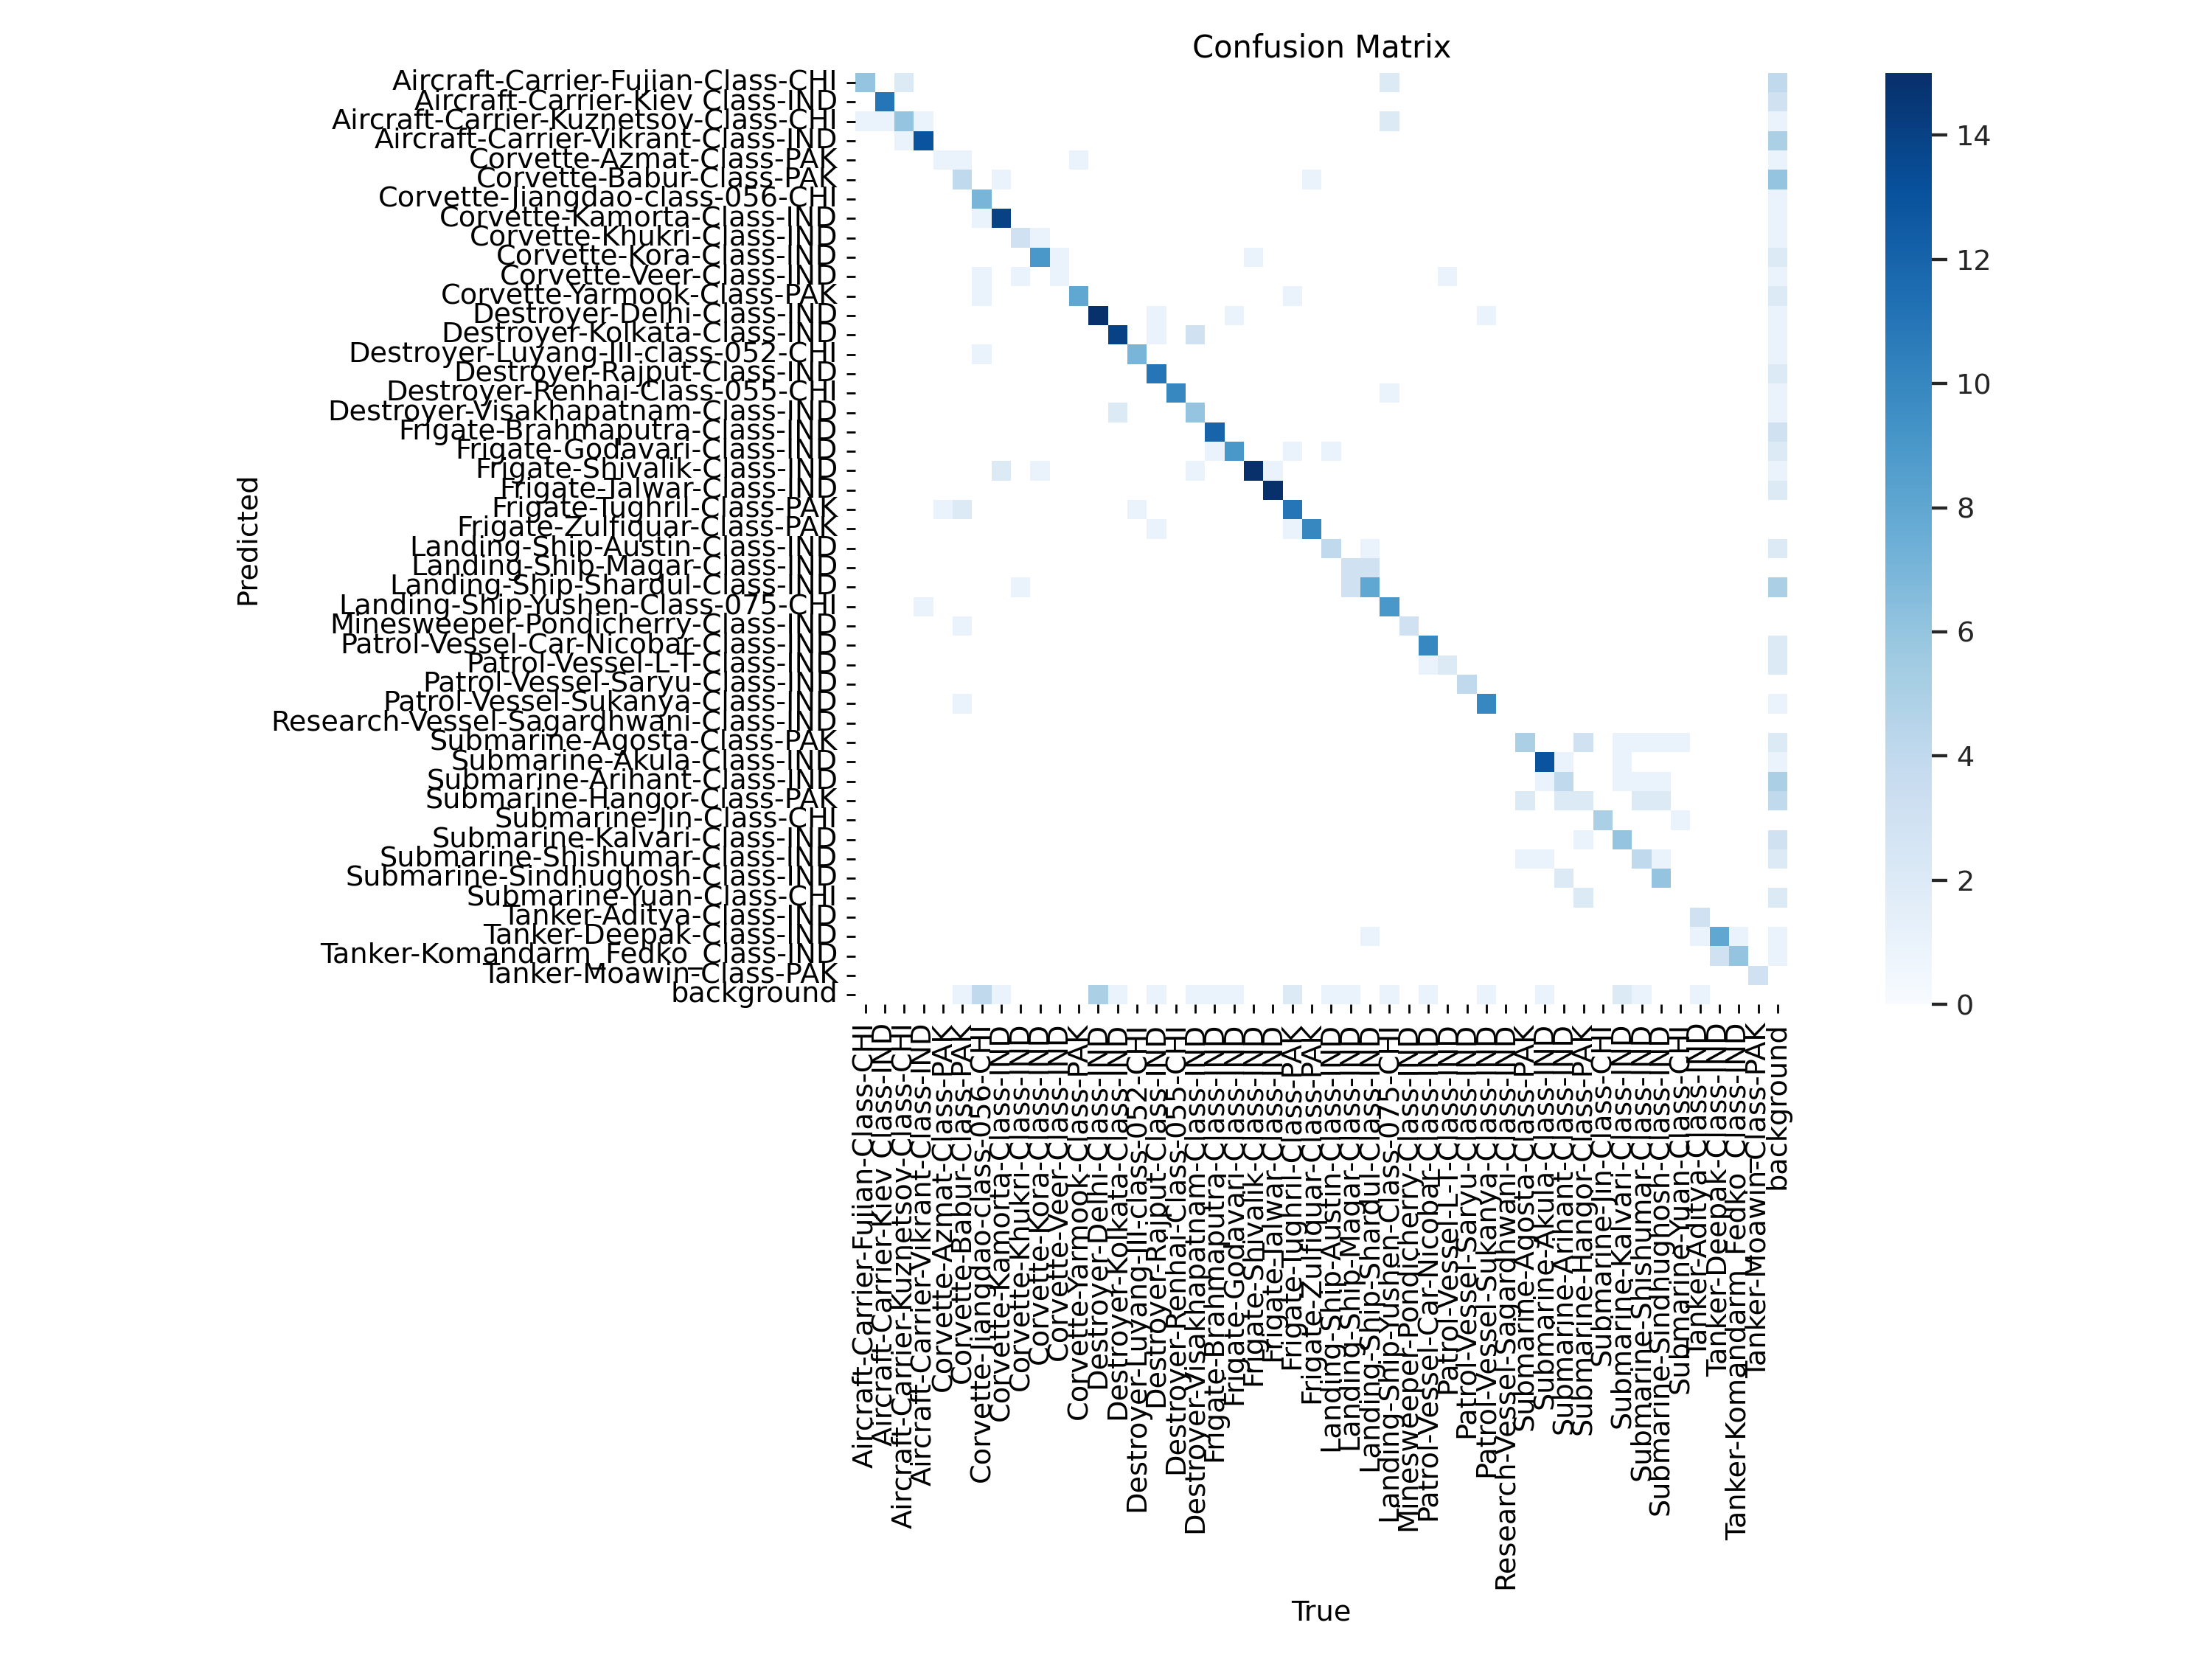

In [21]:
from IPython.display import Image

Image(filename=f'{HOME}/datasets/runs/detect/train/confusion_matrix.png', width=1000)

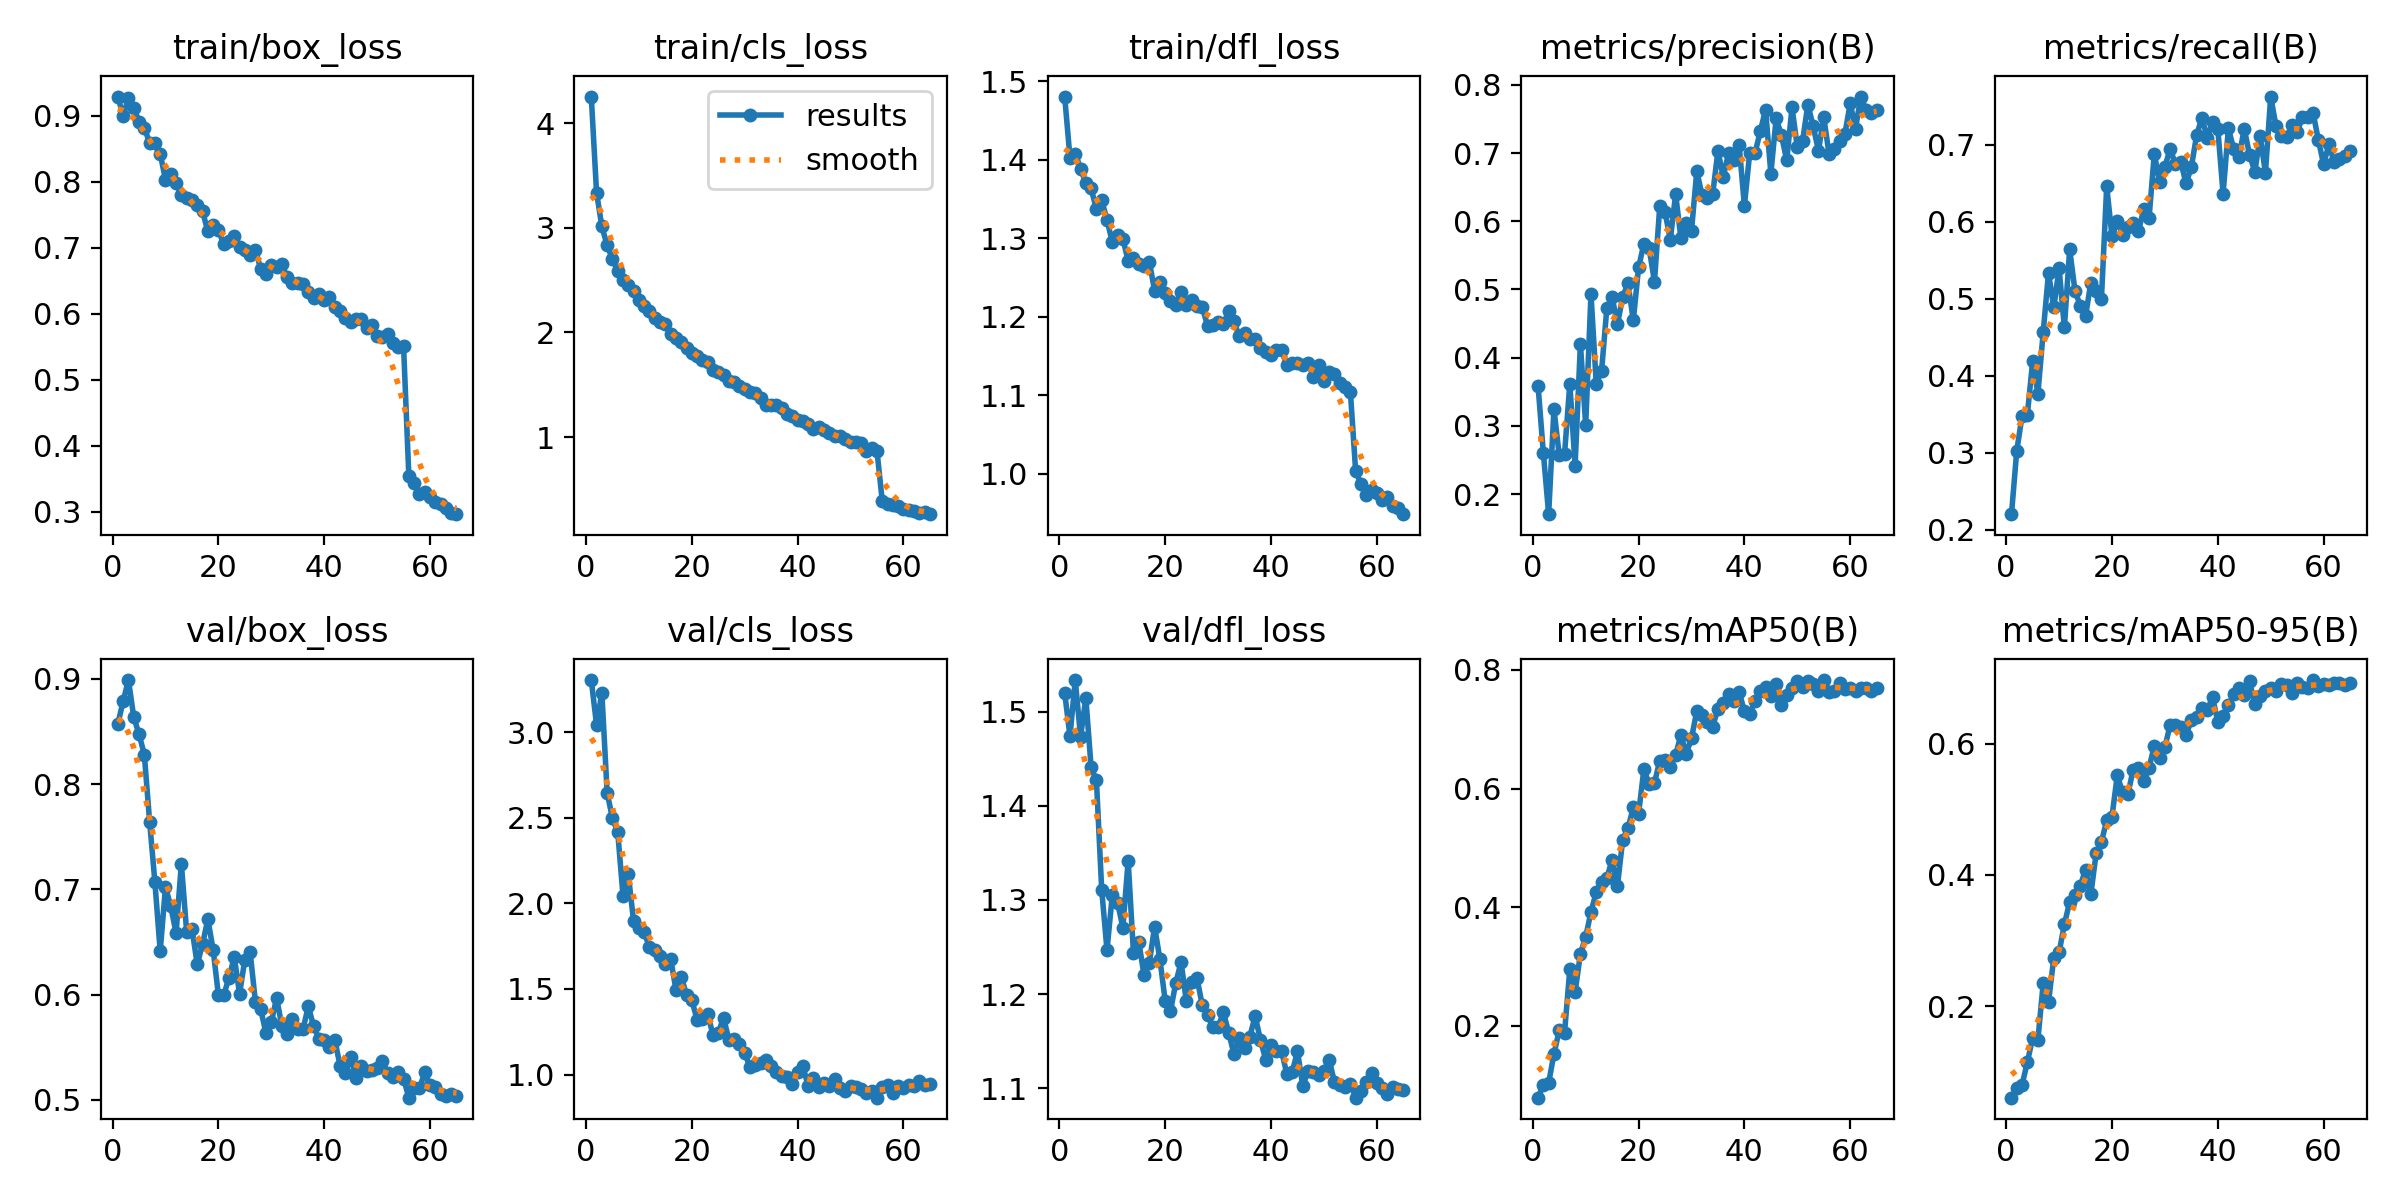

In [22]:
from IPython.display import Image

Image(filename=f'{HOME}/datasets/runs/detect/train/results.png', width=1000)

In [23]:
import supervision as sv

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

ds.classes

['Aircraft-Carrier-Fujian-Class-CHI',
 'Aircraft-Carrier-Kiev Class-IND',
 'Aircraft-Carrier-Kuznetsov-Class-CHI',
 'Aircraft-Carrier-Vikrant-Class-IND',
 'Corvette-Azmat-Class-PAK',
 'Corvette-Babur-Class-PAK',
 'Corvette-Jiangdao-class-056-CHI',
 'Corvette-Kamorta-Class-IND',
 'Corvette-Khukri-Class-IND',
 'Corvette-Kora-Class-IND',
 'Corvette-Veer-Class-IND',
 'Corvette-Yarmook-Class-PAK',
 'Destroyer-Delhi-Class-IND',
 'Destroyer-Kolkata-Class-IND',
 'Destroyer-Luyang-III-class-052-CHI',
 'Destroyer-Rajput-Class-IND',
 'Destroyer-Renhai-Class-055-CHI',
 'Destroyer-Visakhapatnam-Class-IND',
 'Frigate-Brahmaputra-Class-IND',
 'Frigate-Godavari-Class-IND',
 'Frigate-Shivalik-Class-IND',
 'Frigate-Talwar-Class-IND',
 'Frigate-Tughril-Class-PAK',
 'Frigate-Zulfiquar-Class-PAK',
 'Landing-Ship-Austin-Class-IND',
 'Landing-Ship-Magar-Class-IND',
 'Landing-Ship-Shardul-Class-IND',
 'Landing-Ship-Yushen-Class-075-CHI',
 'Minesweeper-Pondicherry-Class-IND',
 'Patrol-Vessel-Car-Nicobar-Class-

In [24]:
from supervision.metrics import MeanAveragePrecision

model = YOLO(f'/{HOME}/datasets/runs/detect/train/weights/best.pt')

predictions = []
targets = []

for _, image, target in ds:
    results = model(image, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)

    predictions.append(detections)
    targets.append(target)

map = MeanAveragePrecision().update(predictions, targets).compute()

In [25]:
print("mAP 50:95", map.map50_95)
print("mAP 50", map.map50)
print("mAP 75", map.map75)

mAP 50:95 0.5981648225612834
mAP 50 0.6714423646012019
mAP 75 0.622186694353326


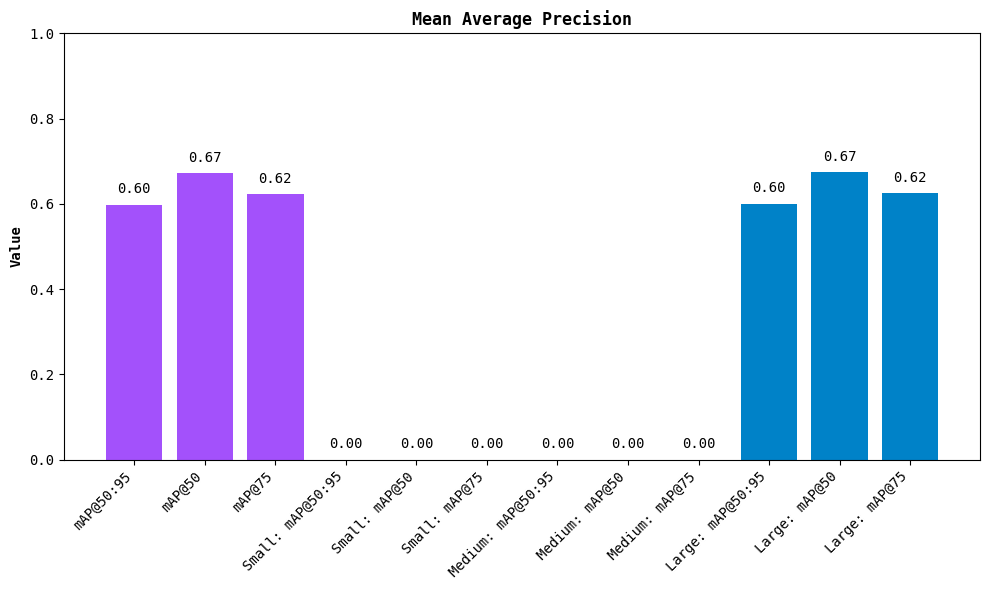

In [26]:
map.plot()

## Run inference with fine-tuned YOLOv12 model

In [27]:
import supervision as sv

model = YOLO(f'/{HOME}/datasets/runs/detect/train/weights/best.pt')

ds = sv.DetectionDataset.from_yolo(
    images_directory_path=f"{dataset.location}/test/images",
    annotations_directory_path=f"{dataset.location}/test/labels",
    data_yaml_path=f"{dataset.location}/data.yaml"
)

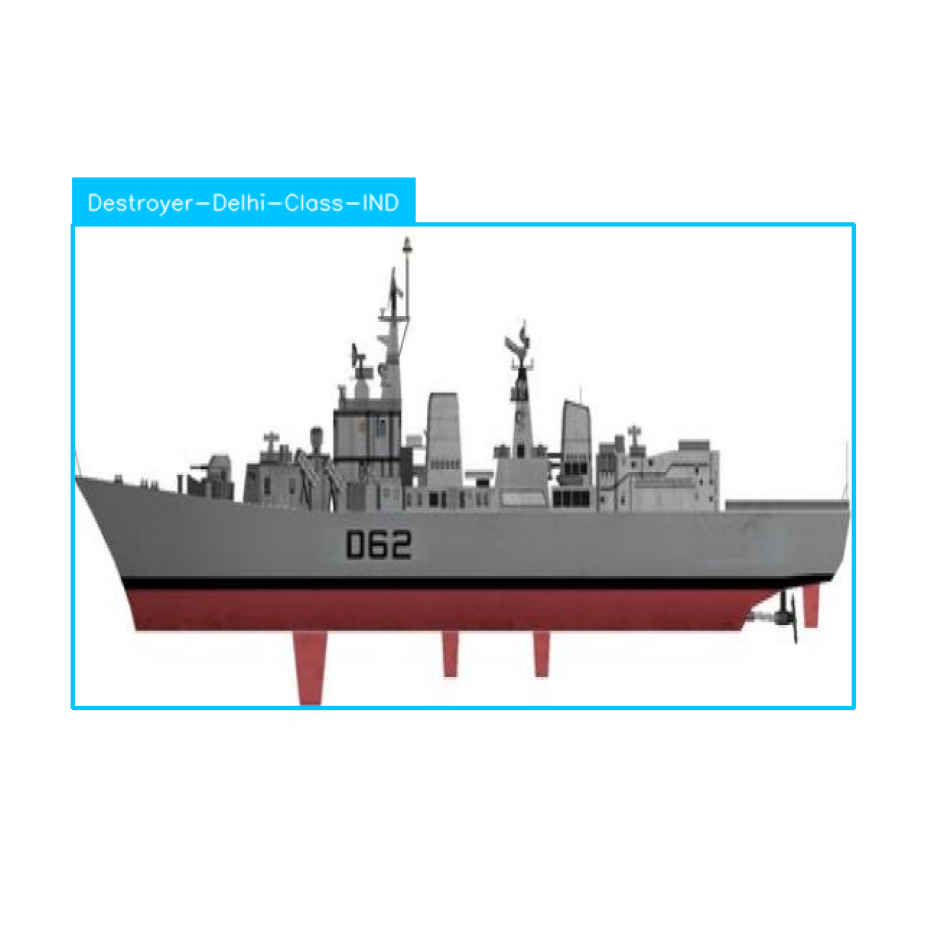

In [28]:
import random
import supervision as sv
import cv2

# Assuming ds is your dataset and model is your trained model
i = random.randint(0, len(ds) - 1)  # Ensure the index is within the valid range
image_path, image, target = ds[i]

# Get model predictions
results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

# Create a copy of the image to annotate
annotated_image = image.copy()

# Extract bounding boxes and class IDs from detections
boxes = detections.xyxy  # Bounding boxes in [x_min, y_min, x_max, y_max] format
class_ids = detections.class_id  # Class IDs for each detection

# Get class names from the model
class_names = model.names  # Assuming model.names contains the class names

# Create annotators
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# Draw bounding boxes
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)

# Add labels to the bounding boxes
labels = [f"{class_names[class_id]}" for class_id in class_ids]
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

# Plot the image with bounding boxes and labels
sv.plot_image(annotated_image)

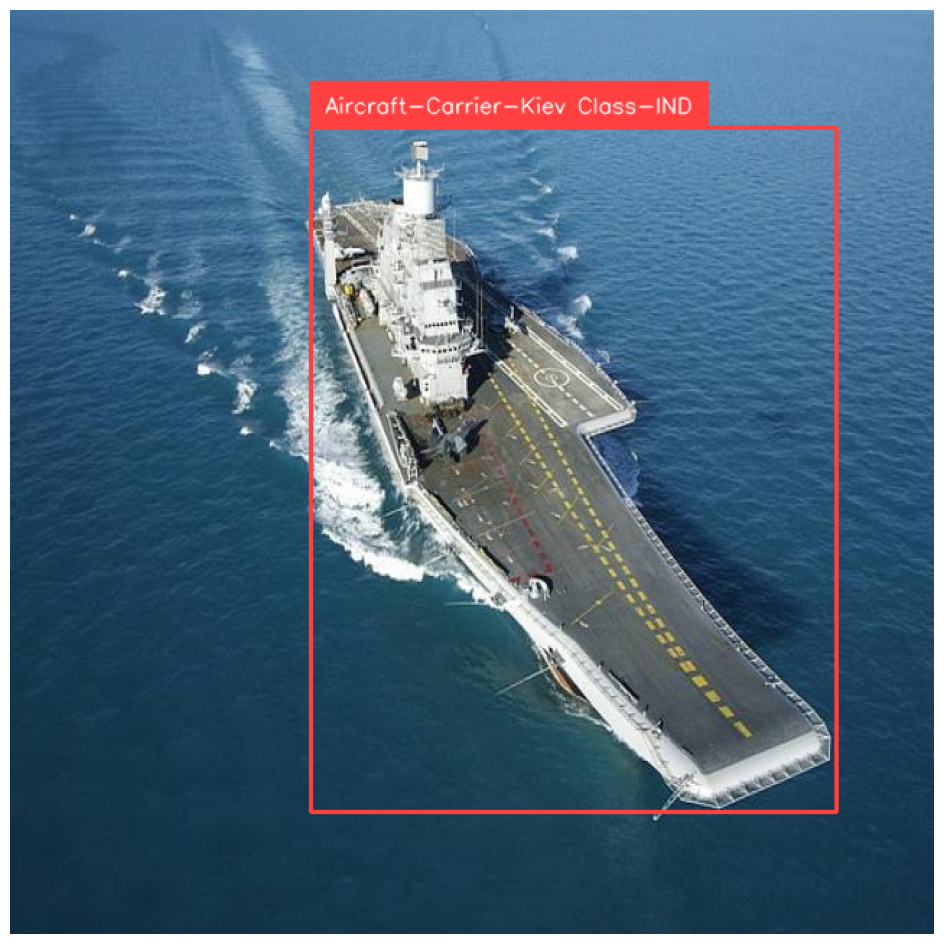

In [30]:
import random
import supervision as sv
import cv2

# Assuming ds is your dataset and model is your trained model
i = random.randint(0, len(ds) - 1)  # Ensure the index is within the valid range
image_path, image, target = ds[i]

# Get model predictions
results = model(image, verbose=False)[0]
detections = sv.Detections.from_ultralytics(results).with_nms()

# Create a copy of the image to annotate
annotated_image = image.copy()

# Extract bounding boxes and class IDs from detections
boxes = detections.xyxy  # Bounding boxes in [x_min, y_min, x_max, y_max] format
class_ids = detections.class_id  # Class IDs for each detection

# Get class names from the model
class_names = model.names  # Assuming model.names contains the class names

# Create annotators
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

# Draw bounding boxes
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)

# Add labels to the bounding boxes
labels = [f"{class_names[class_id]}" for class_id in class_ids]
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections, labels=labels)

# Plot the image with bounding boxes and labels
sv.plot_image(annotated_image)

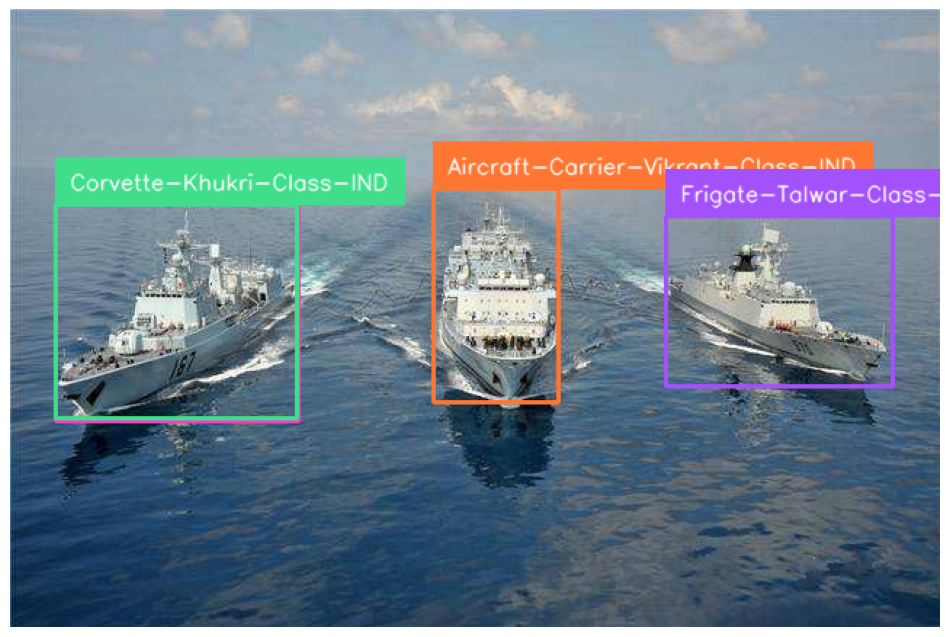

In [55]:
#image_path = f"{HOME}/dog.jpeg"
image_path = '/tf.jpg'

image = cv2.imread(image_path)

model = YOLO('runs/detect/train/weights/best.pt')

results = model(image, conf=0.1, verbose=False)[0]  # conf=0.1 au lieu de 0.25
detections = sv.Detections.from_ultralytics(results)

box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

annotated_image = image.copy()
annotated_image = box_annotator.annotate(scene=annotated_image, detections=detections)
annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

sv.plot_image(annotated_image)

In [54]:
print("Classes détectées :", [model.names[i] for i in detections.class_id])


Classes détectées : ['Frigate-Zulfiquar-Class-PAK', 'Landing-Ship-Austin-Class-IND']


In [56]:
model.save('runs/detect/train/weights/best.pt')
